<h1 style="text-align:center;">Integrate experimental Ala-scan / X-scan data with AF3 models</h1>

In [1]:
import glob
import os
import pandas as pd
import pickle
import numpy as np

from anarci import anarci
from Bio.PDB import PDBParser, NeighborSearch, PDBIO, Superimposer, MMCIFParser
from Bio.SeqUtils import seq1

import matplotlib.pyplot as plt
import seaborn as sns

from Bio.PDB.SASA import ShrakeRupley

# High confidence models

In [10]:
topdir = '../260202_YF-modes/data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

threshold = 0.5

lst=[]
for batch in batches:
    batch_short = batch.split('/')[0]
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    df = pd.read_csv(csv_file)
    df = df[(df["TEMPOproblem"].isna()) & (df['AF3_iptm_pair_mean'] > threshold)]
    df['batch'] = batch_short
    lst.append(df)

df = pd.concat(lst)
df = df[['id', 'batch', 'cdr1_TRA', 'cdr2_TRA', 'cdr3_TRA', 'cdr1_TRB', 'cdr2_TRB', 'cdr3_TRB', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ']]

df.to_csv('AF_models_high_conf.csv', index=False)


# Compute CDR epitope distances
- consider alpha-/beta chains with same V-segment and CDR3 length as experimentally tested TCR

In [ ]:
def extract_cdr_resids(pdb_path, cdr_dict, chain_map={"TRA":"A","TRB":"B"}):
    """
    Extract residue id of CDRs based on the respective sequences.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pdb", pdb_path)
    
    cdr_resids = {}
    for cdr_name, cdr_seq in cdr_dict.items():
        # get tcr chain
        chain_id = chain_map[cdr_name.split('_')[-1]]
        chain_obj = structure[0][chain_id]

        # Get all residues with C-alpha
        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]

        # Convert 3-letter PDB codes to 1-letter
        seq = "".join([seq1(res.get_resname()) for res in residues])
 
        # find CDR sequence in the chain sequence
        L = len(cdr_seq)
        start_idx = seq.find(cdr_seq)
        if start_idx == -1:
            print(f"Warning: CDR {cdr_name} sequence not found in chain {chain_id} of {pdb_path}")
            return None
        
        end_idx = start_idx + L
        
        # extract cdr resids
        resids = np.array([res.get_id()[1] for res in residues[start_idx:end_idx]])
        cdr_resids[cdr_name] = resids

    return cdr_resids

def compute_cdr_min_distances(pdb_file, cdr_resids, chain_map, pmhc_chains=("A","E")):
    """
    Extract minimal distances between CDR residues and pMHC.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("tcr", pdb_file)
    
    # Collect all atoms of pMHC chains
    pmhc_atoms = []
    for chain_id in pmhc_chains:
        chain = structure[0][chain_id]
        pmhc_atoms.extend([atom for atom in chain.get_atoms() if atom.element != "H"])
    ns = NeighborSearch(pmhc_atoms)
    
    cdr_distances = {}
    
    for cdr, res_nums in cdr_resids.items():
        # figure out which TCR chain this cdr belongs to
        if "TRA" in cdr:
            tcr_chain_id = chain_map["TRA"]
        else:
            tcr_chain_id = chain_map["TRB"]
        
        chain = structure[0][tcr_chain_id]
        distances = []
        
        for res_num in res_nums:
            try:
                res = chain[(' ', res_num, ' ')]  # ('HETATM flag', resid, insertion)
            except KeyError:
                distances.append(np.nan)
                continue
            
            # get all heavy atoms
            res_atoms = [atom for atom in res.get_atoms() if atom.element != "H"]
            
            # compute min distance of this residue to pMHC atoms
            if res_atoms:
                min_dist = min(atom - pmhc_atom for atom in res_atoms for pmhc_atom in pmhc_atoms)
                distances.append(min_dist)
            else:
                distances.append(np.nan)
        
        cdr_distances[cdr] = np.array(distances)
    
    return cdr_distances

    

In [53]:
topdir = '../260202_YF-modes/data_julien'
batches = {'LAU5013': 'LAU5013/YF_LAU5013_sc_WT', 
           'Public_Data':'Public_Data/YF_public_pairedData_20251010'}

df = pd.read_csv('AF_models_high_conf.csv')

# select alpha-/beta chains with same V-segment and CDR3 length as experimentally tested TCR
dico = {'A' : ['TRAV12-2', 'TRAJ30', 10],
        'B' : ['TRBV28', 'TRBJ2-7', 13]}

for chain, features in dico.items():
    df_chain = df[(df[f'TR{chain}V'] == features[0]) & (df[f'TR{chain}J'] == features[1]) & (df[f'cdr3_TR{chain}'].str.len() == features[2])]

    lst = []
    for idx, row in df_chain.iterrows():
        tcr_id = row['id']
        batch_short = row['batch']

        pdb_file = f'{topdir}/{batches[batch_short]}/model_pdb_align_exp/{tcr_id}.pdb'
        chain_map={"TRA":"B","TRB":"C"}

        # get residue ids
        cdr_dict = {cdr: str(row[cdr]).upper() for cdr in [f"cdr1_TR{chain}",f"cdr2_TR{chain}",f"cdr3_TR{chain}"]}
        cdr_resids = extract_cdr_resids(pdb_file, cdr_dict, chain_map)

        # get pMHC distance
        cdr_min_distances = compute_cdr_min_distances(pdb_file, cdr_resids, chain_map)
        
        res_ids = []
        for cdr, seq in cdr_dict.items():
            for cnt, residue in enumerate(seq):
                tmp = cdr.split('_')
                if cdr.startswith('cdr3'):
                    id = f'{tmp[0][-1]}{tmp[1][-1]}_{cnt+1:02d}'
                else:
                    id = f'{tmp[0][-1]}{tmp[1][-1]}_{cnt+1}{residue}'
                res_ids.append(id)

        results = pd.DataFrame()
        results['resid'] = np.array(res_ids)
        results['min_dist'] = np.concatenate(list(cdr_min_distances.values()))
        results['tcr_id'] = tcr_id
        lst.append(results)

    results = pd.concat(lst)
    results.to_pickle(f'min_dist_chain{chain}.pkl')

# Integrate with AlaScan Data

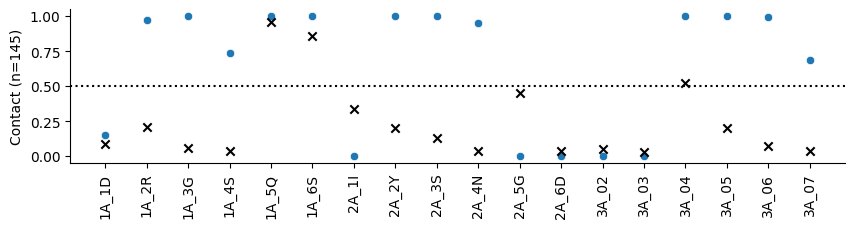

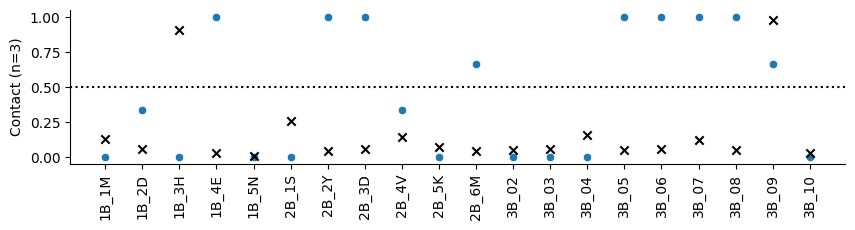

In [87]:
chains = ['A', 'B']

for chain in chains:
    df = pd.read_pickle(f'min_dist_chain{chain}.pkl')

    # convert distances to contacts
    df['contact'] = np.where(df['min_dist'] < 5, 1, 0)

    # fraction of contacts for each resid
    df_mean = df.groupby('resid', as_index=False)['contact'].mean()

    # experimental data
    df_exp = pd.read_csv('YF-AlaScan.csv', sep=';')
    df_exp = df_exp[df_exp['Name'] != 'template']
    df_exp['chain'] = df_exp['Name'].str[4]
    df_exp = df_exp[df_exp['chain'] == chain]

    df_exp['Name_mod'] = np.where(
    df_exp['Name'].str.startswith('CDR3'),
    df_exp['Name'].str[3:6] + df_exp['Name'].str[-2].astype(int).map('{:02d}'.format),
    df_exp['Name'].str[3:6] + df_exp['Name'].str[-2] + df_exp['Name'].str[-3]
    )
    df_exp['resid'] = np.where(df_exp['Name_mod'] == '3B_00', '3B_10', df_exp['Name_mod'])
    df_exp['Results_mod'] = (100 - df_exp['Results']) / 100
    df_exp = df_exp[['resid', 'Results_mod']]
    df_exp.to_pickle(f'YF-AlaScan_chain{chain}.pkl')

    tmp = pd.merge(df_mean, df_exp, on='resid')
    fig, ax = plt.subplots(1,1,figsize=(10,2))
    sns.scatterplot(tmp, x='resid', y='contact', ax=ax, legend=False)
    sns.scatterplot(tmp, x='resid', y='Results_mod', ax=ax, legend=False, color='black', marker='x', linewidth=1.5)

    ax.tick_params(axis='x', rotation=90)
    ax.set_xlabel('')
    ax.set_ylabel(f'Contact (n={len(np.unique(df['tcr_id']))})')
    ax.axhline(0.5, color='black', linestyle=':')
    sns.despine()

# Correlate AlaScan data with plddt

In [82]:
def extract_cdr_plddt(cif_path, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}):
    """
    Extract plddt of CDRs based on the respective sequences.
    """

    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("cif", cif_path)
    model = structure[0]

    cdr_plddt = {}

    for chain_label, chain_id in chain_map.items():
        chain_obj = model[chain_id]

        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join(seq1(res.get_resname()) for res in residues)

        cdr_dict_chain = {}
        for key, value in cdr_dict.items():
            if key.endswith(chain_id[-1]):
                cdr_dict_chain[key] = value

        for cdr, cdr_seq in cdr_dict_chain.items():
            L = len(cdr_seq)

            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: {cdr} not found in {chain_id} of {cif_path}")
                continue

            end_idx = start_idx + L
    
            plddts = []

            for res in residues[start_idx:end_idx]:
                res_plddts = []
                for atom in res.get_atoms():
                    res_plddts.append(atom.get_bfactor())

                plddts.append(np.mean(res_plddts))


            cdr_plddt[cdr] = np.array(plddts)/100

    return cdr_plddt


In [83]:
topdir = '../260202_YF-modes/data_julien'
batches = {'LAU5013': 'LAU5013/YF_LAU5013_sc_WT', 
           'Public_Data':'Public_Data/YF_public_pairedData_20251010'}

df = pd.read_csv('AF_models_high_conf.csv')

# select alpha-/beta chains with same V-segment and CDR3 length as experimentally tested TCR
dico = {'A' : ['TRAV12-2', 'TRAJ30', 10],
        'B' : ['TRBV28', 'TRBJ2-7', 13]}

for chain, features in dico.items():
    df_chain = df[(df[f'TR{chain}V'] == features[0]) & (df[f'TR{chain}J'] == features[1]) & (df[f'cdr3_TR{chain}'].str.len() == features[2])]

    lst = []
    for idx, row in df_chain.iterrows():
        tcr_id = row['id']
        batch_short = row['batch']

        cif_file = f'{topdir}/{batches[batch_short]}/model/{tcr_id}_model.cif'
        chain_map={"TRA":"B","TRB":"C"}

        # get residue ids
        cdr_dict = {cdr: str(row[cdr]).upper() for cdr in [f"cdr1_TR{chain}",f"cdr2_TR{chain}",f"cdr3_TR{chain}"]}

        # get plddts
        cdr_plddts = extract_cdr_plddt(cif_file, cdr_dict, chain_map={f"TR{chain}":f"TCR{chain}"})

        res_ids = []
        for cdr, seq in cdr_dict.items():
            for cnt, residue in enumerate(seq):
                tmp = cdr.split('_')
                if cdr.startswith('cdr3'):
                    id = f'{tmp[0][-1]}{tmp[1][-1]}_{cnt+1:02d}'
                else:
                    id = f'{tmp[0][-1]}{tmp[1][-1]}_{cnt+1}{residue}'
                res_ids.append(id)

        results = pd.DataFrame()
        results['resid'] = np.array(res_ids)
        results['plddt'] = np.concatenate(list(cdr_plddts.values()))
        results['tcr_id'] = tcr_id
        lst.append(results)

    results = pd.concat(lst)
    results.to_pickle(f'plddt_chain{chain}.pkl')


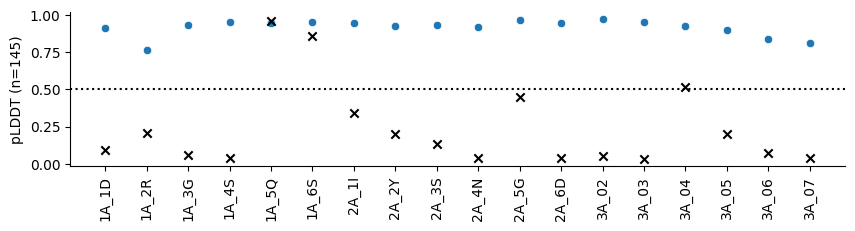

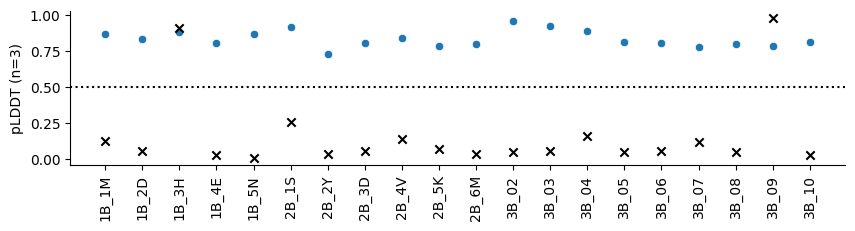

In [88]:
chains = ['A', 'B']

for chain in chains:
    df = pd.read_pickle(f'plddt_chain{chain}.pkl')
    
    df_mean = df.groupby('resid', as_index=False)['plddt'].mean()

    # experimental data
    df_exp = pd.read_pickle(f'YF-AlaScan_chain{chain}.pkl')

    tmp = pd.merge(df_mean, df_exp, on='resid')
    
    fig, ax = plt.subplots(1,1,figsize=(10,2))
    sns.scatterplot(tmp, x='resid', y='plddt', ax=ax, legend=False)
    sns.scatterplot(tmp, x='resid', y='Results_mod', ax=ax, legend=False, color='black', marker='x', linewidth=1.5)

    ax.tick_params(axis='x', rotation=90)
    ax.set_xlabel('')
    ax.set_ylabel(f'pLDDT (n={len(np.unique(df['tcr_id']))})')
    ax.axhline(0.5, color='black', linestyle=':')
    sns.despine()